Entraînement en cours...


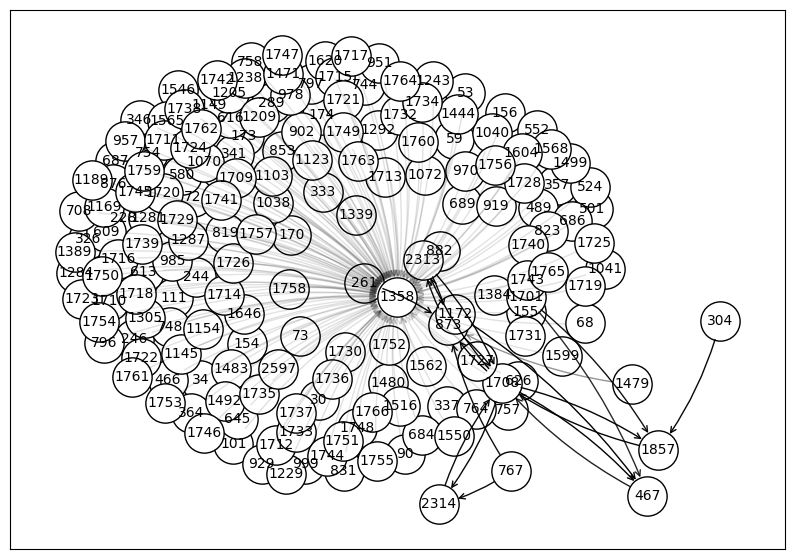

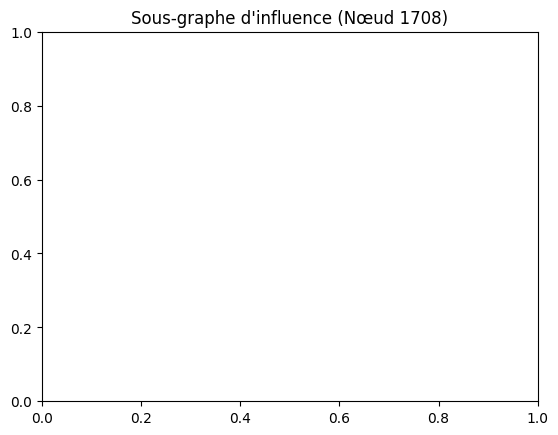

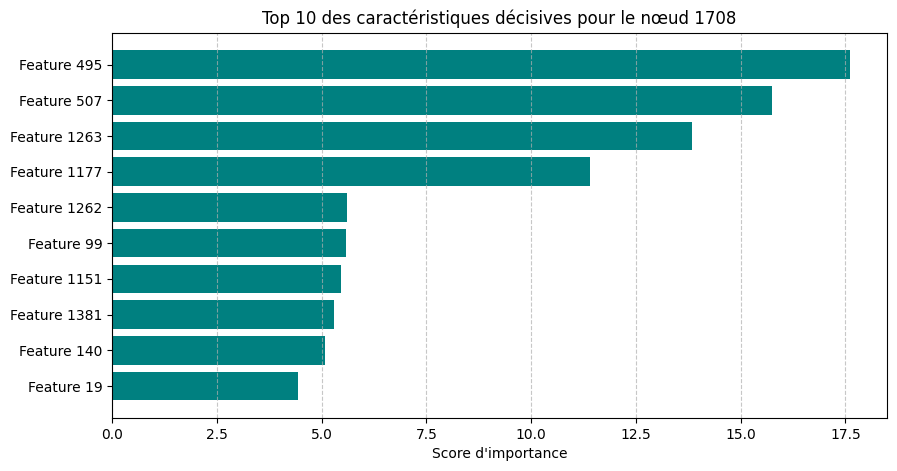

In [9]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
import numpy as np
import networkx as nx

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.utils import to_networkx, k_hop_subgraph

# --- 1. Préparation des données ---
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

# --- 2. Modèle GNN ---
class GNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_node_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.conv2(h, edge_index)
        return h

model = GNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# --- 3. Entraînement ---
print("Entraînement en cours...")
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

model.eval()

# --- 4. Nouvelle API Explainer ---
# Configuration pour expliquer à la fois les liens et les caractéristiques
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='log_probs',
    ),
)

# On choisit un nœud de test au hasard
node_idx = data.test_mask.nonzero(as_tuple=True)[0][0].item()
explanation = explainer(data.x, data.edge_index, index=node_idx)

# --- 5. Visualisations Finales ---

# A. Visualisation du sous-graphe d'importance
plt.figure(figsize=(10, 7))
explanation.visualize_graph(backend="networkx")
plt.title(f"Sous-graphe d'influence (Nœud {node_idx})")
plt.show()

# B. Visualisation des 10 caractéristiques les plus importantes
plt.figure(figsize=(10, 5))
# On récupère l'importance des features (moyenne sur le nœud)
feat_importance = explanation.node_mask.sum(dim=0).cpu().numpy()
indices = np.argsort(feat_importance)[-10:]  # Top 10

plt.barh(range(10), feat_importance[indices], color='teal')
plt.yticks(range(10), [f"Feature {i}" for i in indices])
plt.xlabel("Score d'importance")
plt.title(f"Top 10 des caractéristiques décisives pour le nœud {node_idx}")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()